In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential

import matplotlib.pyplot as plt


In [ ]:
from tensorflow.keras import datasets
(x_train,y_train),(x_test,y_test) = datasets.cifar10.load_data()
print("train shape",x_train.shape)
print("test shape",x_test.shape)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 221s 1us/step
train shape (50000, 32, 32, 3)
test shape (10000, 32, 32, 3)


In [ ]:
x_train=x_train/255.0
x_test=x_test/255.0

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

datagen = ImageDataGenerator(
    rotation_range=15,  # Rotate images by up to 15 degrees
    width_shift_range=0.1, # Shift images horizontally by up to 10% of the width
    height_shift_range=0.1, # Shift images vertically by up to 10% of the height
    horizontal_flip=True, # Flip images horizontally
    zoom_range=0.1 # Zoom in/out by up to 10%
)

datagen.fit(x_train)

In [ ]:
class_names=["airplane","automobile","bird","cat","deer","dog","frog","horse","ship","truck"]

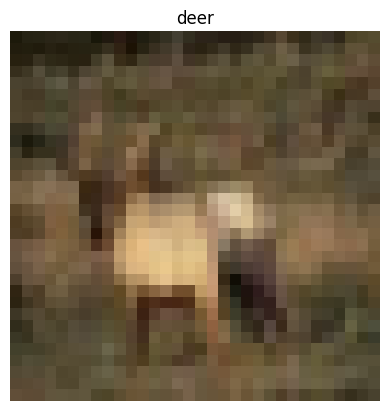

In [ ]:
plt.imshow(x_train[3])
plt.title(class_names[y_train[3][0]])
plt.axis('off')
plt.show()


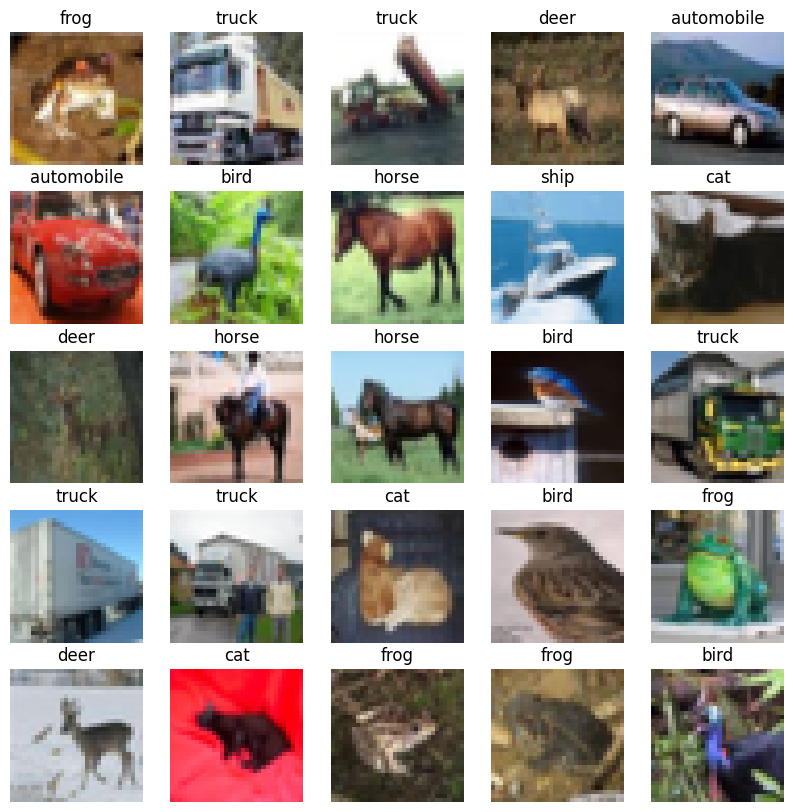

In [ ]:
plt.figure(figsize=(10,10))
for i in range(25): #show 25 img
    plt.subplot(5,5,i+1)
    plt.title(class_names[y_train[i][0]])
    plt.imshow(x_train[i])
    plt.axis('off')
plt.show()

In [ ]:
x_train.shape

(50000, 32, 32, 3)

TRAIN  DS

In [ ]:
from tensorflow.keras import layers
#model=Sequential()
#convolution  +pooling,32-3+0
#depth  30*30*32
#weight --->(3*3*3+1)*32 ---->(F*F*cin+1)*cout
#model.add(layers.Conv2D(32,(3,3),activation='relu',input_shape=(32,32,3)))
#model.add(layers.MaxPooling2D((2,2)))


#model.add(layers.Conv2D(64,(3,3),activation='relu'))

#flatten layera+dence

#model.add(layers.Flatten())
#model.add(layers.Dense(64,activation='relu'))
#model.add(layers.Dense(10,activation='softmax'))




In [ ]:
from tensorflow.keras import layers
model=tf.keras.models.Sequential()
model.add(layers.Conv2D(32,(3,3),activation='relu',input_shape=(32,32,3)))
model.add(layers.MaxPooling2D((2,2)))
model.add(layers.Conv2D(64,(3,3),activation='relu'))
model.add(layers.MaxPooling2D((2,2)))
model.add(layers.Conv2D(64,(3,3),activation='relu'))
model.add(layers.Flatten())
model.add(layers.Dense(64,activation='relu'))
model.add(layers.Dense(10))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 4, 4, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        65,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 367,712 (1.40 MB)

 Trainable params: 122,570 (478.79 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 245,142 (957.59 KB)

In [ ]:
model.compile(optimizer='adam',loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),metrics=['accuracy'])

In [ ]:
history = model.fit(datagen.flow(x_train, y_train, batch_size=32), epochs=10, validation_data=(x_test, y_test))

Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 40s 24ms/step - accuracy: 0.4813 - loss: 1.4294 - val_accuracy: 0.5665 - val_loss: 1.2083
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 33s 21ms/step - accuracy: 0.5521 - loss: 1.2503 - val_accuracy: 0.6116 - val_loss: 1.1356
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 33s 21ms/step - accuracy: 0.5891 - loss: 1.1589 - val_accuracy: 0.6219 - val_loss: 1.0995
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 33s 21ms/step - accuracy: 0.6201 - loss: 1.0847 - val_accuracy: 0.6363 - val_loss: 1.0453
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 32s 21ms/step - accuracy: 0.6353 - loss: 1.0306 - val_accuracy: 0.6700 - val_loss: 0.9561
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 33s 21ms/step - accuracy: 0.6486 - loss: 0.9965 - val_accuracy: 0.6733 - val_loss: 0.9482
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 33s 21ms/step - accuracy: 0.6649 - loss: 0.9605 - val_accuracy: 0.7028 - val_loss: 0.8719
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 32s 21ms/step - accuracy: 0.6745 -

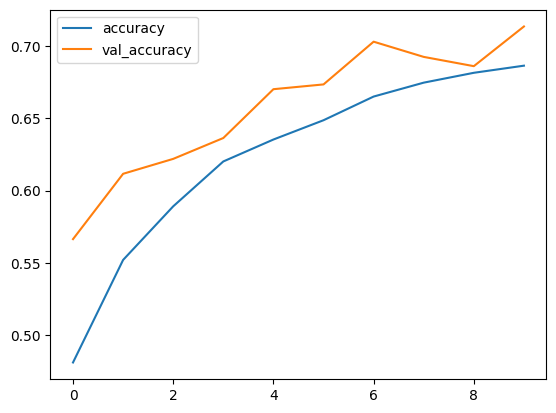

In [ ]:
plt.plot  (history.history['accuracy'],label='accuracy')
plt.plot(history.history['val_accuracy'],label='val_accuracy')
plt.legend()
plt.show()

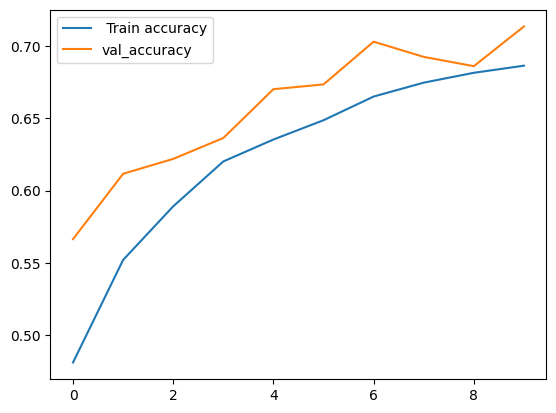

In [ ]:
plt.plot(history.history['accuracy'],label=' Train accuracy')
plt.plot(history.history['val_accuracy'],label='val_accuracy')
plt.legend()
plt.show()

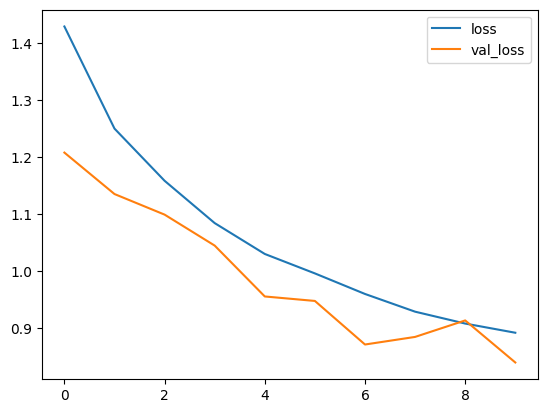

In [ ]:
plt.plot(history.history['loss'],label='loss')
plt.plot(history.history['val_loss'],label='val_loss')
plt.legend()
plt.show()

In [ ]:
import numpy as np
predictions = model.predict(x_test)
data_prediction=np.argmax(predictions,axis=1)
data_prediction

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


array([3, 8, 8, ..., 5, 1, 7])

In [ ]:
import numpy as np

class_names=["airplane","automobile","bird","cat","deer","dog","frog","horse","ship","truck"]

print("predication",class_names[np.argmax(predictions[0])])
print("atuakl",class_names[y_test[1][0]])

predication cat
atuakl ship


In [ ]:
test_loss, test_accuracy = model.evaluate(x_test, y_test, verbose=2)
print(f"Test accuracy: {test_accuracy*100:.2f}%")

313/313 - 1s - 3ms/step - accuracy: 0.7133 - loss: 0.8404
Test accuracy: 71.33%


In [ ]:
def display_predictions_grid(images, actual_labels, predicted_labels, class_names, num_images=25):
    plt.figure(figsize=(12, 12))
    for i in range(num_images):
        plt.subplot(5, 5, i + 1)
        plt.imshow(images[i])
        actual_class = class_names[actual_labels[i][0]]
        predicted_class = class_names[predicted_labels[i]]
        color = 'green' if actual_class == predicted_class else 'red'
        plt.title(f"Act: {actual_class}\nPred: {predicted_class}", color=color)
        plt.axis('off')
    plt.tight_layout()
    plt.show()

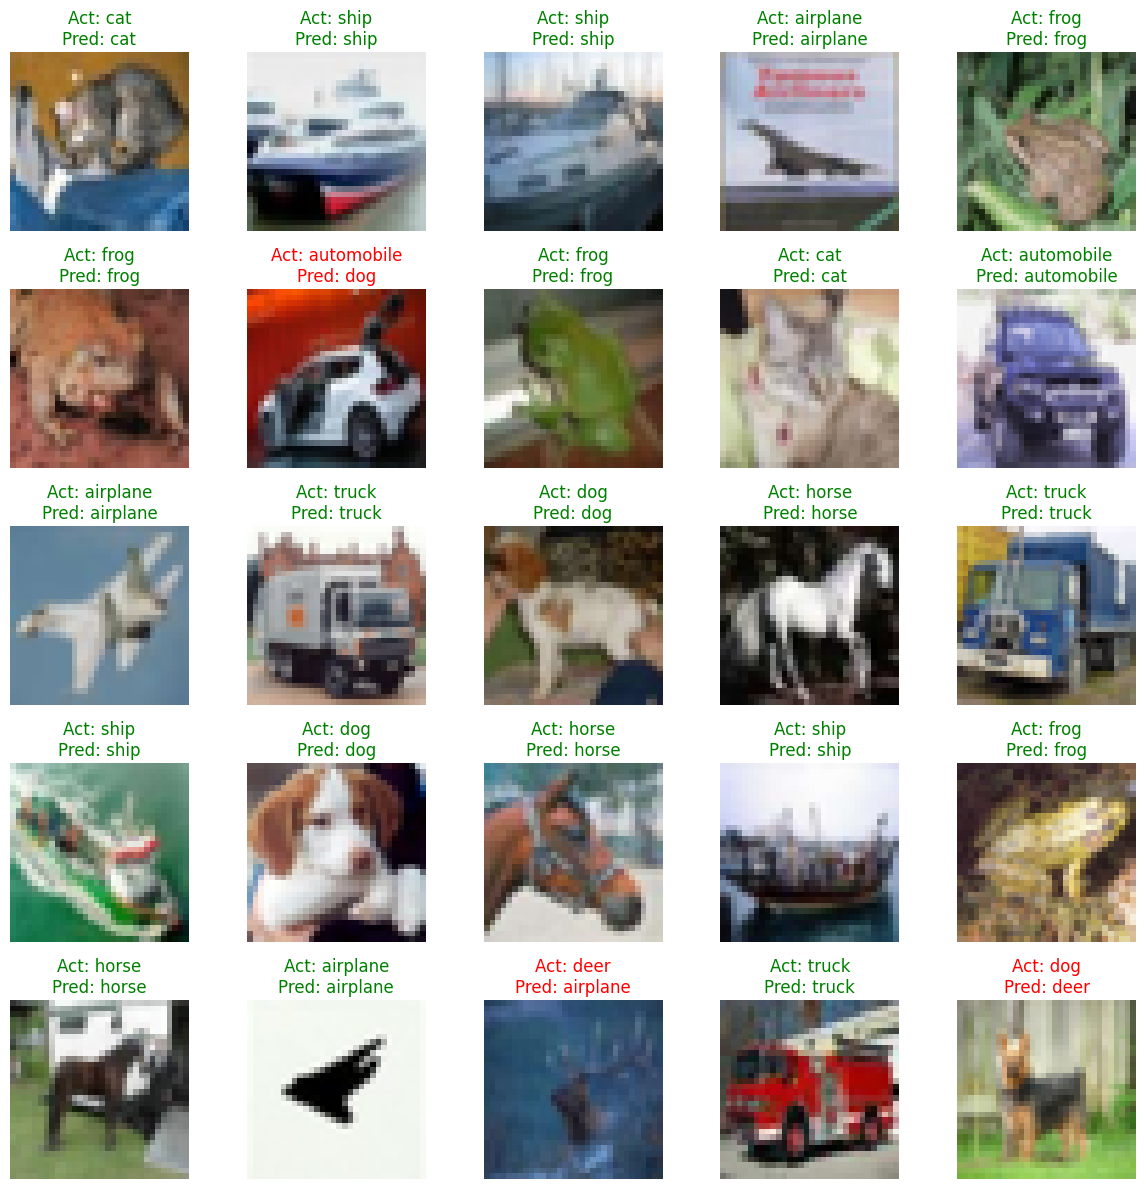

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from tensorflow.keras import datasets

# Re-load and preprocess data if not already defined
if 'x_test' not in globals():
    (x_train,y_train),(x_test,y_test) = datasets.cifar10.load_data()
    x_train=x_train/255.0
    x_test=x_test/255.0

# Re-define class_names if not already defined
if 'class_names' not in globals():
    class_names=["airplane","automobile","bird","cat","deer","dog","frog","horse","ship","truck"]

# Re-generate predictions if not already defined (requires the 'model' to be defined and trained)
if 'data_prediction' not in globals() or data_prediction.dtype != np.int64:
    # Assuming 'model' is already defined and trained from previous steps
    # If 'model' is not defined, this will still raise an error.
    # For a complete fix, ensure previous model definition and training cells are run.
    if 'model' in globals():
        predictions = model.predict(x_test)
        data_prediction = np.argmax(predictions, axis=1)
    else:
        print("Warning: 'model' not found. Cannot generate predictions. Please run model definition and training cells.")
        # Fallback or error handling if model is also missing
        data_prediction = np.zeros(len(y_test), dtype=int) # Placeholder to avoid immediate error with correct dtype

def display_predictions_grid(images, actual_labels, predicted_labels, class_names, num_images=25):
    plt.figure(figsize=(12, 12))
    for i in range(num_images):
        plt.subplot(5, 5, i + 1)
        plt.imshow(images[i])
        actual_class = class_names[actual_labels[i][0]]
        predicted_class = class_names[predicted_labels[i]]
        color = 'green' if actual_class == predicted_class else 'red'
        plt.title(f"Act: {actual_class}\nPred: {predicted_class}", color=color)
        plt.axis('off')
    plt.tight_layout()
    plt.show()

display_predictions_grid(x_test, y_test, data_prediction, class_names, num_images=25)

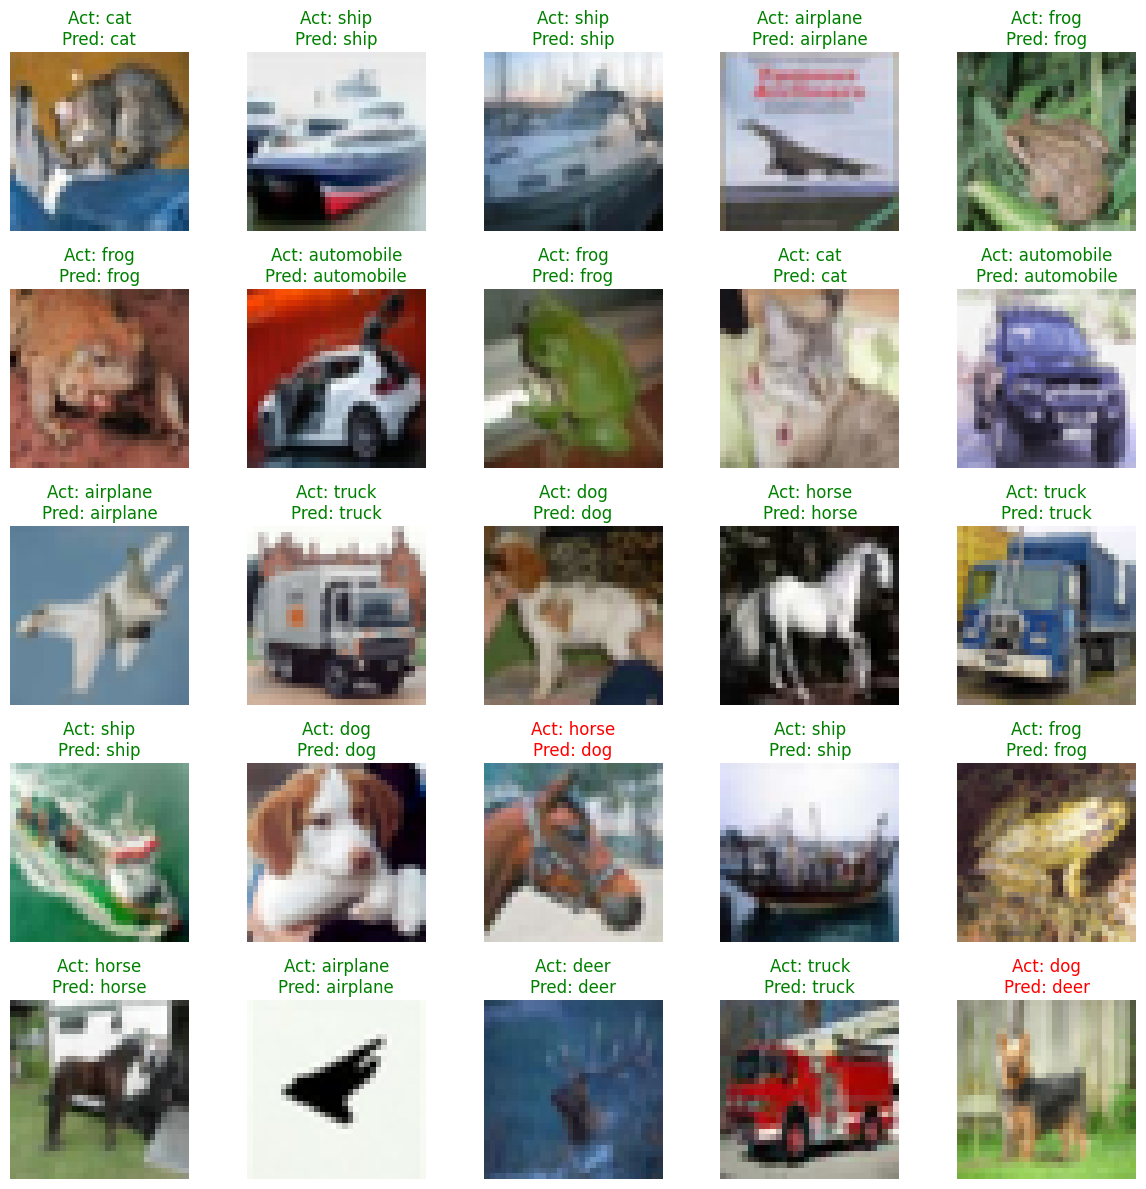

In [ ]:
display_predictions_grid(x_test, y_test, data_prediction, class_names, num_images=25)

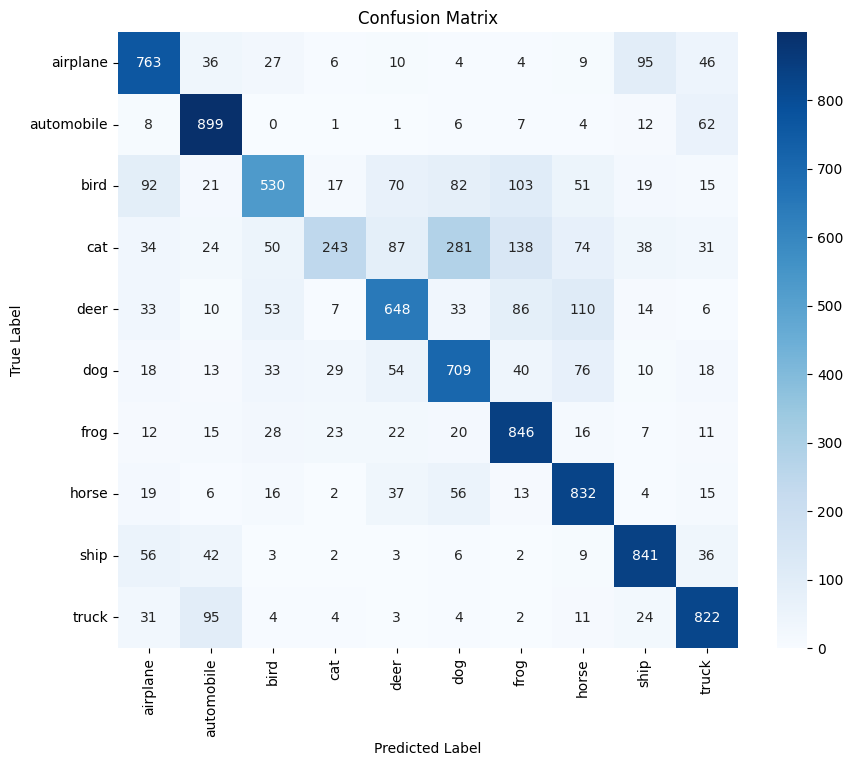

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Calculate the confusion matrix
cm = confusion_matrix(y_test, data_prediction)

# Plot the confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()